In [142]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms as T
from PIL import Image
import pandas as pd
import numpy as np
import random
import os
import copy
import pickle
from collections import defaultdict
from tqdm import tqdm
import math
import textwrap
import matplotlib.pyplot as plt

In [82]:
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")

In [83]:
image_folder = '/dataset/Images/'
caption_folder = '/dataset/captions.txt'

In [84]:
class config:
    ENCODER = "resnet50"
    DECODER = "lstm"
    TRAIN_BATCH_SIZE = 64
    VAL_BATCH_SIZE = 64
    LR = 5e-4
    SEED = 42
    EPOCHS = 15
    EMBED_SIZE = 256
    HIDDEN_SIZE = 512
    NUM_LAYERS = 1
    
    IMAGE_FOLDER_PATH = "dataset/Images"
    CAPTION_FILE_PATH = "dataset/captions.txt"

In [85]:
random.seed(config.SEED)
np.random.seed(config.SEED)
torch.manual_seed(config.SEED)

In [86]:
class CaptionTokenizer:
    def __init__(self):
        self.word2idx = {"<PAD>": 0, "<START>": 1, "<END>": 2, "<UNK>": 3}
        self.idx2word = {0: "<PAD>", 1: "<START>", 2: "<END>", 3: "<UNK>"}
        self.vocab_size = 4
        
    def build_vocab(self, captions, min_freq=5):
        word_freq = defaultdict(int)
        for caption in captions:
            for word in caption.lower().split():
                word_freq[word] += 1
        
        for word, freq in word_freq.items():
            if freq >= min_freq:
                self.word2idx[word] = self.vocab_size
                self.idx2word[self.vocab_size] = word
                self.vocab_size += 1
                
        print(f"Vocabulary size: {self.vocab_size}")
    
    def encode(self, caption, max_length=50):
        tokens = [self.word2idx["<START>"]]
        for word in caption.lower().split():
            tokens.append(self.word2idx.get(word, self.word2idx["<UNK>"]))
        tokens.append(self.word2idx["<END>"])
        
        # Padding
        if len(tokens) < max_length:
            tokens += [self.word2idx["<PAD>"]] * (max_length - len(tokens))
        else:
            tokens = tokens[:max_length]
        
        return tokens
    
    def decode(self, tokens):
        words = []
        for token in tokens:
            word = self.idx2word.get(token, "<UNK>")
            if word == "<END>":
                break
            if word not in ["<PAD>", "<START>"]:
                words.append(word)
        return " ".join(words)


In [87]:
class EncoderCNN(nn.Module):
    def __init__(self, embed_size):
        super(EncoderCNN, self).__init__()
        resnet = models.resnet50(pretrained=True)
        
        # FREEZE WEIGHTS RESNET
        for param in resnet.parameters():
            param.requires_grad = False
        
        # Remove the last fc layer
        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)
        self.fc = nn.Linear(resnet.fc.in_features, embed_size)
        self.bn = nn.BatchNorm1d(embed_size)
        
    def forward(self, images):
        features = self.resnet(images)
        features = features.view(features.size(0), -1)
        features = self.fc(features)
        features = self.bn(features)
        return features

In [88]:
class DecoderLSTM(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super(DecoderLSTM, self).__init__()
        self.embed = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, features, captions):
        embeddings = self.embed(captions)
        # Concatenate image features with caption embeddings
        embeddings = torch.cat((features.unsqueeze(1), embeddings), dim=1)
        hiddens, _ = self.lstm(embeddings)
        outputs = self.fc(self.dropout(hiddens))
        return outputs
    
    def generate(self, features, max_length=50, start_token=1, end_token=2):
        """Generate captions using greedy search"""
        batch_size = features.size(0)
        results = []
        
        for i in range(batch_size):
            feature = features[i].unsqueeze(0)
            sampled_ids = [start_token]
            
            inputs = feature.unsqueeze(1)
            states = None
            
            for _ in range(max_length):
                hiddens, states = self.lstm(inputs, states)
                outputs = self.fc(hiddens.squeeze(1))
                predicted = outputs.argmax(1)
                sampled_ids.append(predicted.item())
                
                if predicted.item() == end_token:
                    break
                
                inputs = self.embed(predicted).unsqueeze(1)
            
            results.append(sampled_ids)
        
        return results

In [89]:
class ImageCaptioningModel(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super(ImageCaptioningModel, self).__init__()
        self.encoder = EncoderCNN(embed_size)
        self.decoder = DecoderLSTM(embed_size, hidden_size, vocab_size, num_layers)
        
    def forward(self, images, captions):
        features = self.encoder(images)
        outputs = self.decoder(features, captions)
        return outputs
    
    def generate_caption(self, images, tokenizer, max_length=50):
        features = self.encoder(images)
        sampled_ids = self.decoder.generate(
            features, 
            max_length=max_length,
            start_token=tokenizer.word2idx["<START>"],
            end_token=tokenizer.word2idx["<END>"]
        )
        return [tokenizer.decode(ids) for ids in sampled_ids]

In [90]:
class ImageCaptioningDataset(Dataset):
    def __init__(self, df, root_dir, tokenizer, transform=None, max_length=50):
        self.df = df
        self.root_dir = root_dir
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row["image"])
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)
        
        caption_tokens = self.tokenizer.encode(row["caption"], self.max_length)
        
        return {
            "image": image,
            "caption": torch.tensor(caption_tokens[:-1]),      # Input: [<START>, A, Cat, sits]
            "target": torch.tensor(caption_tokens)             # Target: [<START>, A, Cat, sits, <END>]
        }

In [91]:
def parse_captions_to_dataframe(csv_file):
    imgid2captions = defaultdict(list)
    
    df = pd.read_csv(csv_file)
    for _, row in df.iterrows():
        img_id, caption = row['image'], row['caption']
        if img_id and isinstance(caption, str):
            imgid2captions[img_id].append(caption)
            
    return df, imgid2captions

In [92]:
full_df, imgid2captions = parse_captions_to_dataframe(config.CAPTION_FILE_PATH)
img_ids = list(imgid2captions.keys())
random.shuffle(img_ids)

In [93]:
train_split_idx = int(0.8 * len(img_ids))
val_split_idx = int(0.9 * len(img_ids))

train_ids = img_ids[:train_split_idx]
val_ids = img_ids[train_split_idx:val_split_idx]
test_ids = img_ids[val_split_idx:]

train_df = full_df[full_df['image'].isin(train_ids)].reset_index(drop=True)
val_df = full_df[full_df['image'].isin(val_ids)].reset_index(drop=True)
test_df = full_df[full_df['image'].isin(test_ids)].reset_index(drop=True)

In [94]:
print(f"Total Images: {len(img_ids)}")
print(f"Training Images: {len(train_ids)} | Training Samples: {len(train_df)}")
print(f"Validation Images: {len(val_ids)} | Validation Samples: {len(val_df)}")
print(f"Test Images: {len(test_ids)}")

Total Images: 8091
Training Images: 6472 | Training Samples: 32360
Validation Images: 809 | Validation Samples: 4045
Test Images: 810


In [95]:
tokenizer = CaptionTokenizer()
tokenizer.build_vocab(train_df['caption'].tolist())

Vocabulary size: 2669


In [96]:
train_transform = T.Compose([
    T.Resize((256, 256)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.Resize((256, 256)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [97]:
train_dataset = ImageCaptioningDataset(train_df, config.IMAGE_FOLDER_PATH, tokenizer, transform=train_transform)
val_dataset = ImageCaptioningDataset(val_df, config.IMAGE_FOLDER_PATH, tokenizer, transform=val_transform)


In [98]:
train_loader = DataLoader(train_dataset, batch_size=config.TRAIN_BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=config.VAL_BATCH_SIZE, shuffle=False, num_workers=0)

In [99]:
model = ImageCaptioningModel(
    embed_size=config.EMBED_SIZE,
    hidden_size=config.HIDDEN_SIZE,
    vocab_size=tokenizer.vocab_size,
    num_layers=config.NUM_LAYERS
).to(DEVICE)

/opt/miniconda3/envs/aol_comvis/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/miniconda3/envs/aol_comvis/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [100]:
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.word2idx["<PAD>"])
optimizer = torch.optim.Adam(model.parameters(), lr=config.LR)

In [101]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for batch in tqdm(loader, desc="Training"):
        images = batch["image"].to(device)
        captions = batch["caption"].to(device)
        targets = batch["target"].to(device)
        
        outputs = model(images, captions)
        loss = criterion(outputs.view(-1, tokenizer.vocab_size), targets.view(-1))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


In [102]:
def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation"):
            images = batch["image"].to(device)
            captions = batch["caption"].to(device)
            targets = batch["target"].to(device)
            
            outputs = model(images, captions)
            loss = criterion(outputs.view(-1, tokenizer.vocab_size), targets.view(-1))
            
            total_loss += loss.item()
    
    return total_loss / len(loader)

In [103]:
best_val_loss = float('inf')
os.makedirs("ResNet50-LSTM-Flickr8k", exist_ok=True)

for epoch in range(config.EPOCHS):
    print(f"\nEpoch {epoch+1}/{config.EPOCHS}")
    
    train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss = validate(model, val_loader, criterion, DEVICE)
    
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'tokenizer': tokenizer
        }, "ResNet50-LSTM-Flickr8k/best_model.pth")
        print(f"✓ Best model saved with val_loss: {val_loss:.4f}")

print("\nTraining completed!")


Epoch 1/15


Validation: 100%|██████████| 64/64 [00:45<00:00,  1.40it/s]


Train Loss: 3.7067 | Val Loss: 3.0634
✓ Best model saved with val_loss: 3.0634

Epoch 2/15


Validation: 100%|██████████| 64/64 [00:44<00:00,  1.44it/s]


Train Loss: 2.9600 | Val Loss: 2.7746
✓ Best model saved with val_loss: 2.7746

Epoch 3/15


...

Train Loss: 1.9958 | Val Loss: 2.3357
✓ Best model saved with val_loss: 2.3357

Epoch 14/15


Validation: 100%|██████████| 64/64 [00:49<00:00,  1.30it/s]


Train Loss: 1.9537 | Val Loss: 2.3319
✓ Best model saved with val_loss: 2.3319

Epoch 15/15


Validation: 100%|██████████| 64/64 [00:47<00:00,  1.36it/s]

Train Loss: 1.9176 | Val Loss: 2.3366

Training completed!


In [122]:
def precook(s, n=4, out=False):
    """
    Takes a string as input and returns an object that can be given to
    either cook_refs or cook_test. This is optional: cook_refs and cook_test
    can take string arguments as well.
    :param s: string : sentence to be converted into ngrams
    :param n: int    : number of ngrams for which representation is calculated
    :return: term frequency vector for occuring ngrams
    """
    words = s.split()
    counts = defaultdict(int)
    for k in range(1,n+1):
        for i in range(len(words)-k+1):
            ngram = tuple(words[i:i+k])
            counts[ngram] += 1
    return counts

def cook_refs(refs, n=4): ## lhuang: oracle will call with "average"
    '''Takes a list of reference sentences for a single segment
    and returns an object that encapsulates everything that BLEU
    needs to know about them.
    :param refs: list of string : reference sentences for some image
    :param n: int : number of ngrams for which (ngram) representation is calculated
    :return: result (list of dict)
    '''
    return [precook(ref, n) for ref in refs]

def cook_test(test, n=4):
    '''Takes a test sentence and returns an object that
    encapsulates everything that BLEU needs to know about it.
    :param test: list of string : hypothesis sentence for some image
    :param n: int : number of ngrams for which (ngram) representation is calculated
    :return: result (dict)
    '''
    return precook(test, n, True)

class CiderScorer(object):
    """CIDEr scorer.
    """

    def copy(self):
        ''' copy the refs.'''
        new = CiderScorer(n=self.n)
        new.ctest = copy.copy(self.ctest)
        new.crefs = copy.copy(self.crefs)
        return new

    def __init__(self, test=None, refs=None, n=4, sigma=6.0):
        ''' singular instance '''
        self.n = n
        self.sigma = sigma
        self.crefs = []
        self.ctest = []
        self.document_frequency = defaultdict(float)
        self.cook_append(test, refs)
        self.ref_len = None

    def cook_append(self, test, refs):
        '''called by constructor and __iadd__ to avoid creating new instances.'''

        if refs is not None:
            self.crefs.append(cook_refs(refs))
            if test is not None:
                self.ctest.append(cook_test(test)) ## N.B.: -1
            else:
                self.ctest.append(None) # lens of crefs and ctest have to match

    def size(self):
        assert len(self.crefs) == len(self.ctest), "refs/test mismatch! %d<>%d" % (len(self.crefs), len(self.ctest))
        return len(self.crefs)

    def __iadd__(self, other):
        '''add an instance (e.g., from another sentence).'''

        if type(other) is tuple:
            ## avoid creating new CiderScorer instances
            self.cook_append(other[0], other[1])
        else:
            self.ctest.extend(other.ctest)
            self.crefs.extend(other.crefs)

        return self
    def compute_doc_freq(self):
        '''
        Compute term frequency for reference data.
        This will be used to compute idf (inverse document frequency later)
        The term frequency is stored in the object
        :return: None
        '''
        for refs in self.crefs:
            # refs, k ref captions of one image
            for ngram in set([ngram for ref in refs for (ngram,count) in ref.items()]):
                self.document_frequency[ngram] += 1
            # maxcounts[ngram] = max(maxcounts.get(ngram,0), count)

    def compute_cider(self, df_mode):
        def counts2vec(cnts):
            """
            Function maps counts of ngram to vector of tfidf weights.
            The function returns vec, an array of dictionary that store mapping of n-gram and tf-idf weights.
            The n-th entry of array denotes length of n-grams.
            :param cnts:
            :return: vec (array of dict), norm (array of float), length (int)
            """
            vec = [defaultdict(float) for _ in range(self.n)]
            length = 0
            norm = [0.0 for _ in range(self.n)]
            for (ngram,term_freq) in cnts.items():
                # give word count 1 if it doesn't appear in reference corpus
                df = np.log(max(1.0, self.document_frequency[ngram]))
                # ngram index
                n = len(ngram)-1
                # tf (term_freq) * idf (precomputed idf) for n-grams
                vec[n][ngram] = float(term_freq)*(self.ref_len - df)
                # compute norm for the vector.  the norm will be used for computing similarity
                norm[n] += pow(vec[n][ngram], 2)

                if n == 1:
                    length += term_freq
            norm = [np.sqrt(n) for n in norm]
            return vec, norm, length

        def sim(vec_hyp, vec_ref, norm_hyp, norm_ref, length_hyp, length_ref):
            '''
            Compute the cosine similarity of two vectors.
            :param vec_hyp: array of dictionary for vector corresponding to hypothesis
            :param vec_ref: array of dictionary for vector corresponding to reference
            :param norm_hyp: array of float for vector corresponding to hypothesis
            :param norm_ref: array of float for vector corresponding to reference
            :param length_hyp: int containing length of hypothesis
            :param length_ref: int containing length of reference
            :return: array of score for each n-grams cosine similarity
            '''
            delta = float(length_hyp - length_ref)
            # measure consine similarity
            val = np.array([0.0 for _ in range(self.n)])
            for n in range(self.n):
                # ngram
                for (ngram,count) in vec_hyp[n].items():
                    # vrama91 : added clipping
                    val[n] += min(vec_hyp[n][ngram], vec_ref[n][ngram]) * vec_ref[n][ngram]

                if (norm_hyp[n] != 0) and (norm_ref[n] != 0):
                    val[n] /= (norm_hyp[n]*norm_ref[n])

                assert(not math.isnan(val[n]))
                # vrama91: added a length based gaussian penalty
                val[n] *= np.e**(-(delta**2)/(2*self.sigma**2))
            return val

        # compute log reference length
        if df_mode == "corpus":
            self.ref_len = np.log(float(len(self.crefs)))
        elif df_mode == "coco-val-df":
            # if coco option selected, use length of coco-val set
            self.ref_len = np.log(float(40504))

        scores = []
        for test, refs in zip(self.ctest, self.crefs):
            # compute vector for test captions
            vec, norm, length = counts2vec(test)
            # compute vector for ref captions
            score = np.array([0.0 for _ in range(self.n)])
            for ref in refs:
                vec_ref, norm_ref, length_ref = counts2vec(ref)
                score += sim(vec, vec_ref, norm, norm_ref, length, length_ref)
            # change by vrama91 - mean of ngram scores, instead of sum
            score_avg = np.mean(score)
            # divide by number of references
            score_avg /= len(refs)
            # multiply score by 10
            score_avg *= 10.0
            # append score of an image to the score list
            scores.append(score_avg)
        return scores

    def compute_score(self, df_mode, option=None, verbose=0):
        # compute idf
        if df_mode == "corpus":
            self.compute_doc_freq()
            # assert to check document frequency
            assert(len(self.ctest) >= max(self.document_frequency.values()))
            # import json for now and write the corresponding files
        else:
            self.document_frequency = pickle.load(open(os.path.join('data', df_mode + '.p'),'r'))
        # compute cider score
        score = self.compute_cider(df_mode)
        # debug
        # print score
        return np.mean(np.array(score)), np.array(score)
    
class CiderD:
    """
    Main Class to compute the CIDEr metric

    """
    def __init__(self, n=4, sigma=6.0, df="corpus"):
        # set cider to sum over 1 to 4-grams
        self._n = n
        # set the standard deviation parameter for gaussian penalty
        self._sigma = sigma
        # set which where to compute document frequencies from
        self._df = df

    def compute_score(self, gts, res):
        """
        Main function to compute CIDEr score
        :param  hypo_for_image (dict) : dictionary with key <image> and value <tokenized hypothesis / candidate sentence>
                ref_for_image (dict)  : dictionary with key <image> and value <tokenized reference sentence>
        :return: cider (float) : computed CIDEr score for the corpus
        """

        cider_scorer = CiderScorer(n=self._n)

        for res_id in res:

            hypo = res_id['caption']
            ref = gts[res_id['image_id']]

            # Sanity check.
            assert(type(hypo) is list)
            assert(len(hypo) == 1)
            assert(type(ref) is list)
            assert(len(ref) > 0)
            cider_scorer += (hypo[0], ref)

        (score, scores) = cider_scorer.compute_score(self._df)

        return score, scores

    def method(self):
        return "CIDEr-D"

In [123]:
def clean_caption(caption):
    caption = caption.strip().lower()

    caption = ' '.join(caption.split())

    return caption

In [124]:
checkpoint = torch.load("ResNet50-LSTM-Flickr8k/best_model.pth", map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']} with val_loss: {checkpoint['val_loss']:.4f}")

Loaded best model from epoch 13 with val_loss: 2.3319


In [125]:
class TestDataset(Dataset):
    def __init__(self, image_ids, root_dir, transform):
        self.image_ids = image_ids
        self.root_dir = root_dir
        self.transform = transform
        
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        img_name = self.image_ids[idx]
        img_path = os.path.join(self.root_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image_tensor = self.transform(image)
            
        return image_tensor, img_name

In [ ]:
test_unique_images = test_df['image'].unique().tolist()
print(f"Generating captions for {len(test_unique_images)} test images...")

Generating captions for 810 test images...


In [127]:
test_candidate_list = []
test_reference_dict = {}

model.eval()

with torch.no_grad():
    # 1. Change the iterator to your test image list
    for idx, img_name in enumerate(tqdm(test_unique_images, desc="Evaluating Test")):
        
        # 2. Adjust path if test images are in a different folder 
        # (e.g., config.TEST_IMAGE_FOLDER_PATH)
        image_path = os.path.join(config.IMAGE_FOLDER_PATH, img_name)
        image = Image.open(image_path).convert("RGB")
        
        # 3. Apply transform (usually the same transform used for validation)
        image_tensor = val_transform(image).unsqueeze(0).to(DEVICE)
        
        # Generate caption
        generated_ids = model.generate_caption(image_tensor, tokenizer, max_length=50)
        candidate_caption = generated_ids[0]
        
        # Clean caption
        candidate_caption = clean_caption(candidate_caption)
        
        # Add to test candidate list
        test_candidate_list.append({
            "image_id": idx,
            "caption": [candidate_caption]
        })
        
        # 4. Get reference captions
        # IMPORTANT: Ensure imgid2captions has the keys for test images
        if img_name in imgid2captions:
            test_reference_dict[idx] = [clean_caption(ref) for ref in imgid2captions[img_name]]
        else:
            print(f"Warning: No reference captions found for {img_name}")
            test_reference_dict[idx] = [""]

# Compute CIDEr-D score for Test
print(f"\nComputing CIDEr-D score for {len(test_candidate_list)} test images...")
ciderD = CiderD(df="corpus")
test_cider_score, test_cider_scores = ciderD.compute_score(test_reference_dict, test_candidate_list)
print(f"Test CIDEr-D Score: {test_cider_score:.4f}")

Evaluating Test: 100%|██████████| 810/810 [00:35<00:00, 23.02it/s]



Computing CIDEr-D score for 810 test images...
Test CIDEr-D Score: 0.4221



Visualizing random results...


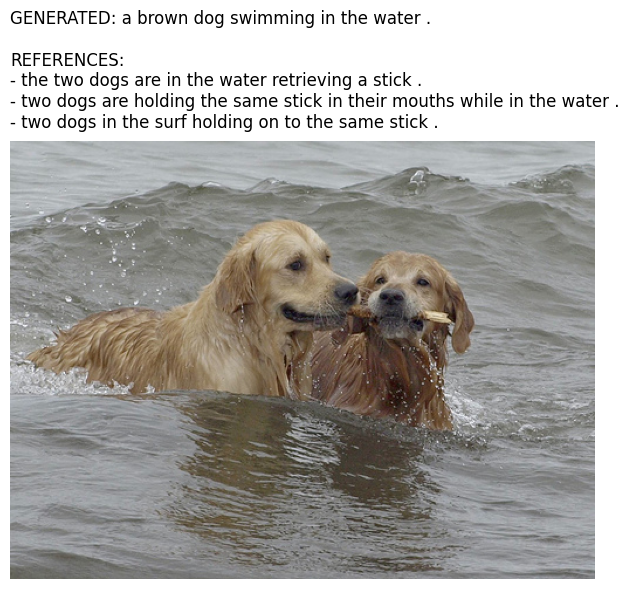

In [ ]:
def visualize_results(image_list, candidates, references, image_folder, num_samples=3):
    """
    image_list: list nama file gambar (test_unique_images)
    candidates: list of dict hasil generate (test_candidate_list)
    references: dict of list referensi (test_reference_dict)
    image_folder: path folder gambar
    num_samples: jumlah gambar yang ingin ditampilkan
    """
    
    total_images = len(image_list)
    indices = random.sample(range(total_images), min(num_samples, total_images))
    
    plt.figure(figsize=(15, 6 * len(indices)))
    
    for i, idx in enumerate(indices):
        img_name = image_list[idx]
        
        gen_item = next((item for item in candidates if item["image_id"] == idx), None)
        gen_caption = gen_item['caption'][0] if gen_item else "Error finding caption"
        ref_captions = references.get(idx, ["No reference found"])
    
        img_path = os.path.join(image_folder, img_name)
        image = Image.open(img_path).convert("RGB")
        
        ax = plt.subplot(len(indices), 1, i + 1)
        ax.imshow(image)
        ax.axis('off')
        wrapped_gen = "\n".join(textwrap.wrap(f"GENERATED: {gen_caption}", width=80))
        
        ref_text_list = [f"- {r}" for r in ref_captions[:3]]
        ref_text_joined = "\n".join(ref_text_list)
        
        title_text = f"{wrapped_gen}\n\nREFERENCES:\n{ref_text_joined}"
        
        ax.set_title(title_text, loc='left', fontsize=12, backgroundcolor='white', pad=10)

    plt.tight_layout()
    plt.show()

print("\nVisualizing random results...")
visualize_results(
    image_list=test_unique_images,
    candidates=test_candidate_list,
    references=test_reference_dict,
    image_folder=config.IMAGE_FOLDER_PATH,
    num_samples=1
)